# **Introduction**



I intend to use the data set called `electricity.csv` “Electricity Demands” found in Kaggle, using as a starting point the feature columns with information about the time of day, day of the week, electricity demand in NSW, electricity price in Victoria, and power transfers between regions. I will use K-Nearest Neighbors and Linear Regression to predict future electricity prices in New South Wales, which is regression, and compare which algorithm is better to predict this information.


In [2]:
from __future__ import print_function
import os
data_path = []

## KNN in one city


* Begin by importing the data. Examine the columns and data.
* We will clean the date a little bit, so we can drop some of the data.

.

In [3]:
import pandas as pd

# Import the data
filepath = os.sep.join(data_path + ['/content/sample_data/electricity.csv'])
data = pd.read_csv(filepath)

data.head(4).T

,0,1,2,3
date,0.0,0.0,0.0,0.0
day,b'2',b'2',b'2',b'2'
period,0.0,0.021277,0.042553,0.06383
nswprice,0.056443,0.051699,0.051489,0.045485
nswdemand,0.439155,0.415055,0.385004,0.314639
vicprice,0.003467,0.003467,0.003467,0.003467
vicdemand,0.422915,0.422915,0.422915,0.422915
transfer,0.414912,0.414912,0.414912,0.414912
class,b'UP',b'UP',b'UP',b'UP'


In [4]:
data.shape


(45312, 9)

In [5]:
data.dtypes

,0
date,float64
day,object
period,float64
nswprice,float64
nswdemand,float64
vicprice,float64
vicdemand,float64
transfer,float64
class,object


In [6]:
data['day'] = (
    data['day']
      .astype(str)
      .str.extract(r'(\d+)')     # grab the digits
      .astype(int)               # convert to int
)

data.head()

,date,day,period,nswprice,nswdemand,vicprice,vicdemand,transfer,class
0,0.0,2,0.000000,0.056443,0.439155,0.003467,0.422915,0.414912,b'UP'
1,0.0,2,0.021277,0.051699,0.415055,0.003467,0.422915,0.414912,b'UP'
2,0.0,2,0.042553,0.051489,0.385004,0.003467,0.422915,0.414912,b'UP'
3,0.0,2,0.063830,0.045485,0.314639,0.003467,0.422915,0.414912,b'UP'
4,0.0,2,0.085106,0.042482,0.251116,0.003467,0.422915,0.414912,b'DOWN'


In [7]:
data.dtypes

,0
date,float64
day,int64
period,float64
nswprice,float64
nswdemand,float64
vicprice,float64
vicdemand,float64
transfer,float64
class,object


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

#Split into features and target

features = ['day','period','nswdemand','vicprice','vicdemand','transfer']
X = data[features]
y = data['nswprice']

#Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

#Fit scaler on training data only
msc = MinMaxScaler()
X_train_scaled = msc.fit_transform(X_train)

#Transform test data with the same scaler
X_test_scaled = msc.transform(X_test)




In [9]:
from sklearn.model_selection import cross_val_score
import numpy as np

ks = range(1, 21)
cvs = []
for k in ks:
    knn = KNeighborsRegressor(n_neighbors=k)
    # Use negative MSE so we can turn it into RMSE
    scores = cross_val_score(knn, X_train_scaled, y_train,
                             cv=5,
                             scoring='neg_mean_squared_error')
    rmse_cv = np.mean(np.sqrt(-scores))
    cvs.append(rmse_cv)

# Find k with lowest CV-RMSE
best_k = ks[np.argmin(cvs)]
print("Best k:", best_k, "with CV-RMSE:", min(cvs))


Best k: 4 with CV-RMSE: 0.03119379724946821


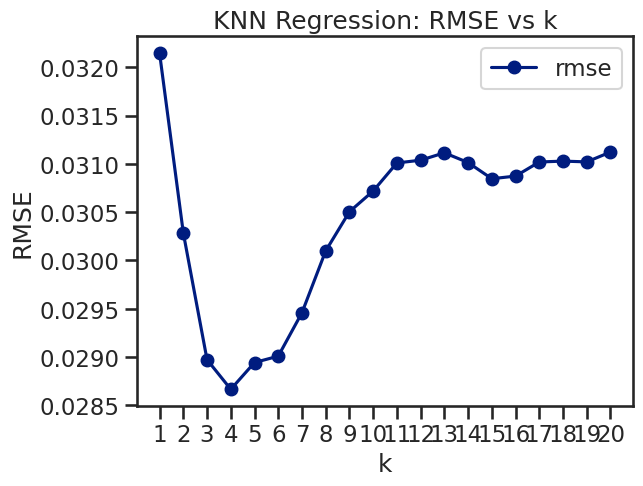

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

%matplotlib inline

# 1. Hyperparameter search over k for KNN Regression
rmse_list = []
for k in range(1, 21):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_list.append((k, rmse))

# 2. Build a DataFrame of results
rmse_df = pd.DataFrame(rmse_list, columns=['k', 'rmse'])

# 3. Plot RMSE vs. k
sns.set_context('talk')
sns.set_style('ticks')
sns.set_palette('dark')

ax = rmse_df.set_index('k').plot(marker='o')
ax.set(xlabel='k', ylabel='RMSE')
ax.set_xticks(range(1, 21))
plt.title('KNN Regression: RMSE vs k')
plt.show()


In [11]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

knn_final = KNeighborsRegressor(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)

y_pred_knn = knn_final.predict(X_test_scaled)
rmse_knn   = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn     = r2_score(y_test, y_pred_knn)

print(f"KNN (k={best_k}) → RMSE: {rmse_knn:.4f}, R²: {r2_knn:.4f}")

KNN (k=4) → RMSE: 0.0287, R²: 0.5053


In [12]:
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.neighbors import KNeighborsRegressor


ks = list(range(1, 21))
cvs = []

for k in ks:
    knn = KNeighborsRegressor(n_neighbors=k)
    # cross_val_score returns an array of 5 negative MSE values
    neg_mses = cross_val_score(
        knn,
        X_train_scaled,
        y_train,
        cv=5,
        scoring='neg_mean_squared_error'
    )
    # Convert to RMSE and take the mean
    rmse_scores = np.sqrt(-neg_mses)
    cvs.append(rmse_scores.mean())

# Now cvs has 20 entries, one per k
best_k_cv = ks[np.argmin(cvs)]
print(f"CV RMSE for k=1..20: {cvs}")
print(f"Best k by CV-RMSE: {best_k_cv}")


CV RMSE for k=1..20: [np.float64(0.03518568921486115), np.float64(0.032307037037178916), np.float64(0.0312610831988988), np.float64(0.03119379724946821), np.float64(0.03141542065737823), np.float64(0.031580238256718726), np.float64(0.03175748485245139), np.float64(0.03165570180266283), np.float64(0.03170073816159059), np.float64(0.03173714287390291), np.float64(0.03181067199605092), np.float64(0.03187201098650512), np.float64(0.03190343424944451), np.float64(0.031912782026882684), np.float64(0.031866912628963136), np.float64(0.03193586203851983), np.float64(0.032006994043961026), np.float64(0.03209996773959678), np.float64(0.03215885437835709), np.float64(0.0322153669433569)]
Best k by CV-RMSE: 4


In [13]:
import pandas as pd

# 1) Put your test-features back into a DataFrame
X_test_unscaled = pd.DataFrame(
    X_test,
    columns=features,
    index=y_test.index
)

# 2) Build a comparison table
comparison = X_test_unscaled.copy()
comparison['Actual_price']    = y_test
comparison['Predicted_price'] = y_pred  # from your KNN

print(comparison.head(10))


       day    period  nswdemand  vicprice  vicdemand  transfer  Actual_price  \
26939    3  0.234043   0.359268  0.003043   0.373641  0.556140      0.046025   
8321     7  0.361702   0.313746  0.003467   0.422915  0.414912      0.089738   
43379    2  0.744681   0.474412  0.002985   0.527965  0.364035      0.043953   
27688    4  0.851064   0.400625  0.001676   0.320818  0.457895      0.024919   
42648    1  0.510638   0.332639  0.003199   0.305541  0.748684      0.049418   
37824    6  0.000000   0.629128  0.009148   0.486794  0.786842      0.139006   
2952     7  0.510638   0.377566  0.003467   0.422915  0.414912      0.041582   
44862    5  0.638298   0.512348  0.009443   0.701450  0.235088      0.089318   
41792    4  0.680851   0.493752  0.004057   0.525634  0.428070      0.065360   
29940    2  0.765957   0.489735  0.001680   0.398757  0.882018      0.026240   

       Predicted_price  
26939         0.054145  
8321          0.069320  
43379         0.055251  
27688         0.034

In [14]:
knn = KNeighborsRegressor(n_neighbors=4)
knn.fit(X_train_scaled, y_train)


KNeighborsRegressor(n_neighbors=4)

In [15]:
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler

# 1) Scale train and test
msc = MinMaxScaler()
X_train_scaled = msc.fit_transform(X_train)
X_test_scaled  = msc.transform(X_test)

# 2) Train final KNN
knn = KNeighborsRegressor(n_neighbors=4)
knn.fit(X_train_scaled, y_train)

# 3) Prepare your new example
new_example = pd.DataFrame(
    [[3, 0.75, 0.50, 0.065, 0.48, 0.30]],
    columns=features
)

# 4) Scale it
new_scaled = msc.transform(new_example)

# 5) Predict
future_price = knn.predict(new_scaled)
print("Forecasted NSW price (KNN):", future_price[0])


Forecasted NSW price (KNN): 0.06009825


# **Logistic Regression and KNN**

Here we using class_label as the y to compare if it went up or went down the price, here is the real comparision


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1) Create a binary label from the 'class' column (UP→1, DOWN→0)
data['class_label'] = (
    data['class']
        .astype(str)                         # e.g. "b'UP'"
        .str.extract(r"b'(\w+)'")[0]         # extracts "UP" or "DOWN"
        .map({'UP': 1, 'DOWN': 0})           # map to 1/0
)

# 2) Define features and the new target
features = ['day','period','nswdemand','vicprice','vicdemand']
X = data[features]
y = data['class_label']

# 3) Stratified train/test split to preserve UP/DOWN ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 4) Scale features
scaler = MinMaxScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 5) Train Logistic Regression classifier
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# 6) Predict & evaluate
y_pred = log_reg.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.649895178197065

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.76      0.71      5215
           1       0.61      0.50      0.55      3848

    accuracy                           0.65      9063
   macro avg       0.64      0.63      0.63      9063
weighted avg       0.64      0.65      0.64      9063

Confusion Matrix:
 [[3979 1236]
 [1937 1911]]


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1) Train Logistic Regression with balanced class weights
log_clf_bal = LogisticRegression(max_iter=1000, class_weight='balanced')
log_clf_bal.fit(X_train_scaled, y_train)

# 2) Predict & evaluate
y_pred_bal = log_clf_bal.predict(X_test_scaled)

print("Balanced LR Accuracy:", accuracy_score(y_test, y_pred_bal))
print("\nClassification Report:\n", classification_report(y_test, y_pred_bal))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_bal))


Balanced LR Accuracy: 0.6305858987090367

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.60      0.65      5215
           1       0.55      0.68      0.61      3848

    accuracy                           0.63      9063
   macro avg       0.63      0.64      0.63      9063
weighted avg       0.65      0.63      0.63      9063

Confusion Matrix:
 [[3113 2102]
 [1246 2602]]


In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1) Train a KNN classifier with k=4
knn_clf = KNeighborsClassifier(n_neighbors=4)
knn_clf.fit(X_train_scaled, y_train)

# 2) Predict on the test set
y_pred_knn = knn_clf.predict(X_test_scaled)

# 3) Evaluate
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nKNN Classification Report:\n", classification_report(y_test, y_pred_knn))
print("KNN Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))


KNN Accuracy: 0.6843208650557211

KNN Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.83      0.75      5215
           1       0.68      0.48      0.56      3848

    accuracy                           0.68      9063
   macro avg       0.68      0.66      0.66      9063
weighted avg       0.68      0.68      0.67      9063

KNN Confusion Matrix:
 [[4347  868]
 [1993 1855]]


In [27]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

# Collect metrics for each model
models = {
    'KNN':           y_pred_knn,
    'LogReg':        y_pred,
    'LogReg_bal':    y_pred_bal
}

rows = []
for name, y_pred_model in models.items():
    acc = accuracy_score(y_test, y_pred_model)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred_model, average='weighted'
    )
    rows.append({
        'Model':        name,
        'Accuracy':     acc,
        'Precision (wtd)': prec,
        'Recall (wtd)':    rec,
        'F1-score (wtd)':  f1
    })

# Display comparison
comparison_df = pd.DataFrame(rows).set_index('Model')
print(comparison_df)


            Accuracy  Precision (wtd)  Recall (wtd)  F1-score (wtd)
Model                                                              
KNN         0.684321         0.683773      0.684321        0.672665
LogReg      0.649895         0.644841      0.649895        0.643377
LogReg_bal  0.630586         0.645793      0.630586        0.632559
